In [1]:
import numpy as np
import matplotlib.pyplot as plt
from regpy.operators.convolution import ConvolutionOperator, GaussianBlur, ExponentialConvolution
from regpy.vecsps import UniformGridFcts
from regpy.solvers import TikhonovRegularizationSetting, RegularizationSetting, RegSolver
from regpy.solvers import DualityGapStopping
from regpy.solvers.linear.semismoothNewton import SemismoothNewton_bilateral, SemismoothNewton_nonneg, SemismoothNewtonAlphaGrid
from regpy.solvers.linear.tikhonov import TikhonovCG
from regpy.solvers.linear.primal_dual import PDHG
from regpy.solvers.linear.proximal_gradient import FISTA
import regpy.functionals as fct
from regpy.hilbert import L2
from regpy.stoprules import CountIterations
from comparison_plot import comparison_plot
import logging

# Generate a test image as exact solution

In [2]:
grid = UniformGridFcts((-1, 1, 256), (-1.5, 1, 256),dtype = float, periodic = True)
"""Space of real-valued functions on a uniform grid with rectangular pixels"""
X = grid.coords[0]; Y = grid.coords[1]
"""x and y coordinates."""
cross = 1.0*np.logical_or((abs(X)<0.01) * (abs(Y)<0.3),(abs(X)<0.3) * (abs(Y)<0.01)) 
rad = np.sqrt(X**2 + Y**2)
ring = 1.0*np.logical_and(rad>=0.9, rad<=0.925)
smallbox = (abs(X+0.55)<=0.05) * (abs(Y-0.55)<=0.05)
bubbles = (1.001+np.sin(50/(X+1.3)))*np.exp(-((Y+1.25)/0.1)**2)*(X>-0.8)*(X<0.8)

ramp = Y<=-1

objects = 50*(ring + 2.0*cross + 1.5*smallbox + 2*ramp -bubbles)
exact_sol = objects 


# Generate synthetic data with impulsive noise

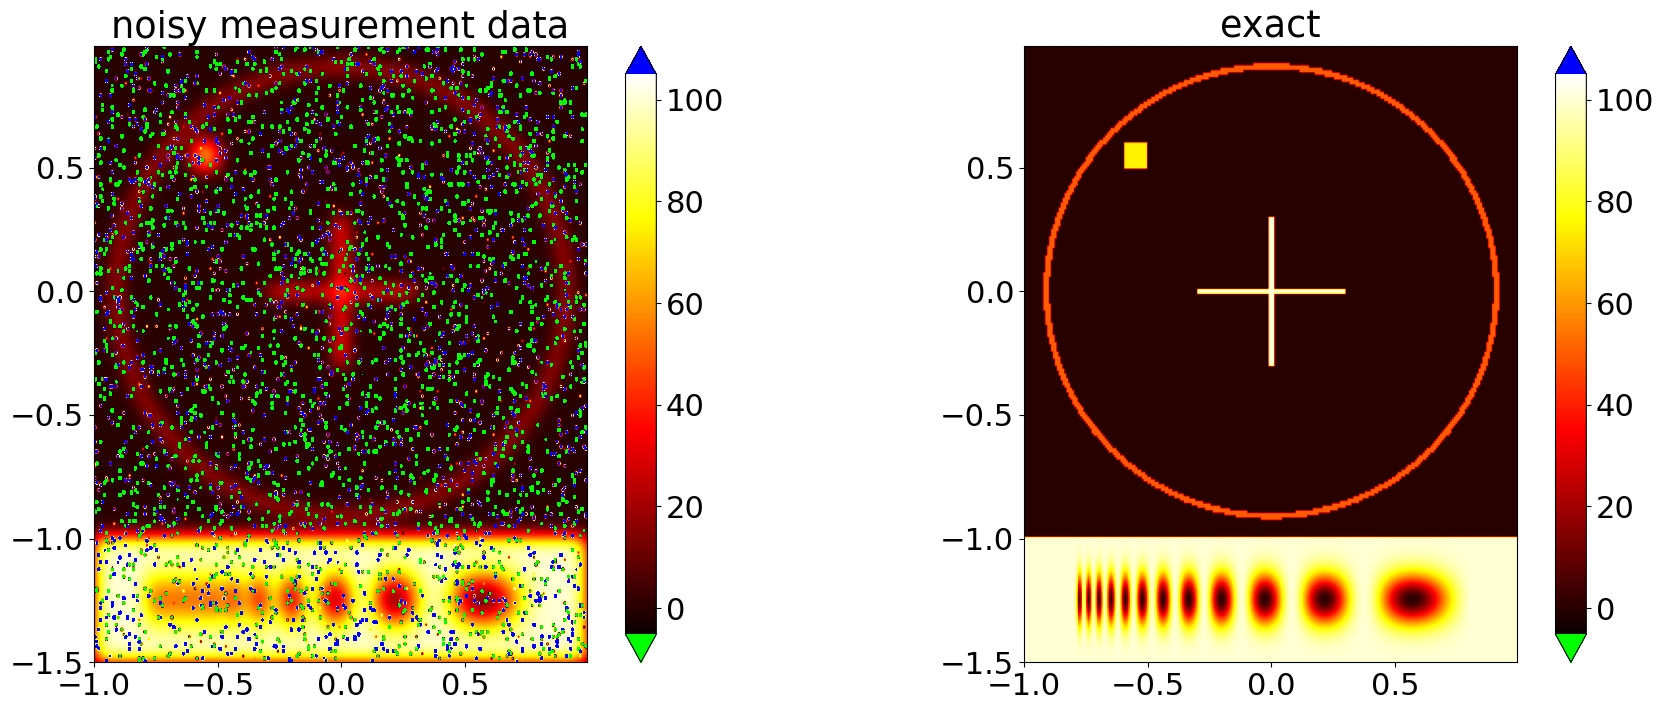

In [3]:
a=0.05
conv =  GaussianBlur(grid,a,pad_amount=((16,16),(16,16)))
"""Convolution operator \(f\mapsto h*f\) for the convolution kernel \(h(x)=\exp(-|x|_2^2/a^2)\)."""
blur = conv(exact_sol)
blur[blur<0] = 0.
data = blur.copy()
n,m=grid.shape
for j in range(64**2):
    nn = np.random.randint(n)
    mm = np.random.randint(m)
    data[nn,mm] =  np.random.randint(2000)-1000

comparison_plot(grid,exact_sol,data,title_left='noisy measurement data')

# Reconstruction with a quadratic data fidelity term
... fails completely for this data!

2024-07-07 18:49:12,251 INFO TikhonovCG           :: it.746 kappa=25.65681208057186 err/Tol rel X:1.0e-06/1.0e-06 
2024-07-07 18:49:12,253 INFO TikhonovCG           :: Solver converged after 746 iteration.


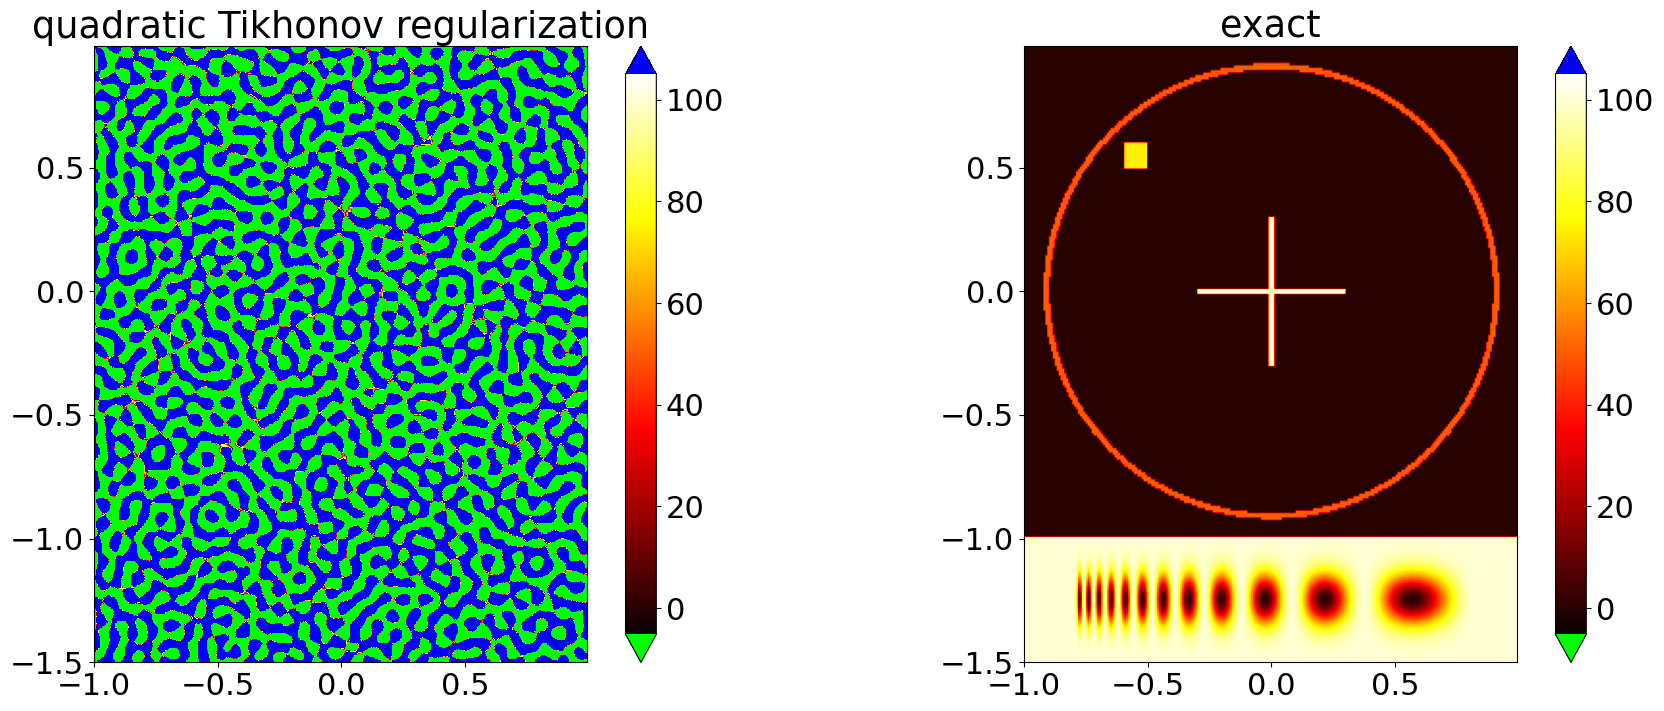

In [4]:
alpha = 1e-4
setting = RegularizationSetting(conv,L2,L2)
solver = TikhonovCG(setting=setting, data = data, regpar = alpha,reltolx=1e-6)
fal,_ = solver.run()

comparison_plot(grid,exact_sol,fal,title_left='quadratic Tikhonov regularization')

# setting with Huber data fidelity and quadratic penalty term
We now set up a generalized Tikhonov regularization setting
$$
\hat{f} \in \mathrm{argmin}_f\left[\frac{1}{\alpha}H_{\sigma}(Tf-g^{\mathrm{obs}})+\|f\|^2\right]    
$$
where the Huber data fidelity term $H_{\sigma}$ is quadratic on coordinates in $[-\sigma,\sigma]$ and $|\cdot|-\sigma/2$ for large coordinates.

We test three solvers for this setting:
- FISTA applied to the primal problem
- FISTA applied to the dual problem
- Primal-Dual Hybrid Gradient (Chambolle-Pock) method

In [5]:
sigma = 0.1
Sdat = (1./sigma)*fct.Huber(grid,sigma=sigma,eps =1e-10)
huber_setting = TikhonovRegularizationSetting(conv,L2,Sdat,alpha,data_fid_shift=data)
dual_setting = huber_setting.dualSetting()
threshold = 1e-1
max_iter=500

### FISTA applied to primal problem

2024-07-07 18:49:13,738 INFO FISTA                :: Setting up FISTA with convexity parameters mu_R=1.000e-04, mu_S=0.000e+00 and step length tau=1.011e-01.
 Expected linear convergence rate: 9.968e-01
2024-07-07 18:49:13,775 INFO DualityGapStopping   :: it. 0/500: duality gap=1.105e+08 (1.000e-01)
2024-07-07 18:49:13,815 INFO DualityGapStopping   :: it. 1/500: duality gap=1.025e+08 (1.000e-01)
2024-07-07 18:49:13,855 INFO DualityGapStopping   :: it. 2/500: duality gap=9.833e+07 (1.000e-01)
2024-07-07 18:49:13,939 INFO DualityGapStopping   :: it. 3/500: duality gap=9.465e+07 (1.000e-01)
2024-07-07 18:49:14,050 INFO DualityGapStopping   :: it. 4/500: duality gap=9.161e+07 (1.000e-01)
2024-07-07 18:49:14,175 INFO DualityGapStopping   :: it. 5/500: duality gap=8.904e+07 (1.000e-01)
2024-07-07 18:49:14,235 INFO DualityGapStopping   :: it. 6/500: duality gap=8.675e+07 (1.000e-01)
2024-07-07 18:49:14,300 INFO DualityGapStopping   :: it. 7/500: duality gap=8.472e+07 (1.000e-01)
2024-07-07 18

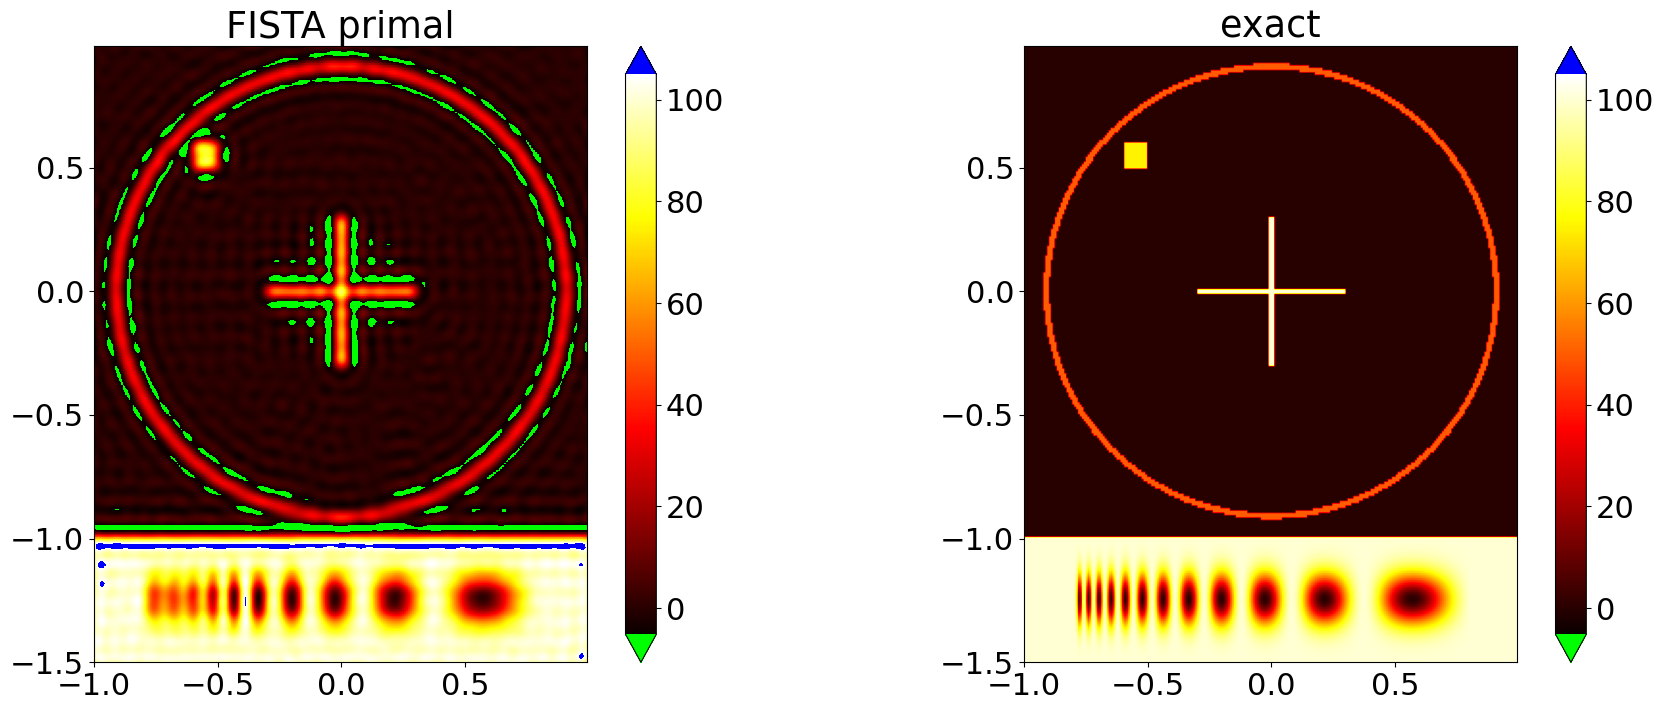

In [6]:
solverFISTA_primal = FISTA(huber_setting,logging_level=logging.DEBUG)
stop_FISTA_primal=DualityGapStopping(solverFISTA_primal,threshold = threshold, max_iter=max_iter,logging_level=logging.INFO)
f_FISTA_primal, _= solverFISTA_primal.run(stoprule=stop_FISTA_primal)

comparison_plot(grid,exact_sol,f_FISTA_primal,title_left='FISTA primal')

### FISTA applied to the dual problem

2024-07-07 18:49:42,947 INFO FISTA                :: Setting up FISTA with convexity parameters mu_R=1.000e-05, mu_S=0.000e+00 and step length tau=1.005e+00.
 Expected linear convergence rate: 9.968e-01
2024-07-07 18:49:43,090 INFO DualityGapStopping   :: it. 0/500: duality gap=2.376e+06 (1.000e-01)
2024-07-07 18:49:43,229 INFO DualityGapStopping   :: it. 1/500: duality gap=1.731e+06 (1.000e-01)
2024-07-07 18:49:43,291 INFO DualityGapStopping   :: it. 2/500: duality gap=1.655e+06 (1.000e-01)
2024-07-07 18:49:43,347 INFO DualityGapStopping   :: it. 3/500: duality gap=1.586e+06 (1.000e-01)
2024-07-07 18:49:43,403 INFO DualityGapStopping   :: it. 4/500: duality gap=1.491e+06 (1.000e-01)
2024-07-07 18:49:43,440 INFO DualityGapStopping   :: it. 5/500: duality gap=1.356e+06 (1.000e-01)
2024-07-07 18:49:43,479 INFO DualityGapStopping   :: it. 6/500: duality gap=1.182e+06 (1.000e-01)
2024-07-07 18:49:43,516 INFO DualityGapStopping   :: it. 7/500: duality gap=9.713e+05 (1.000e-01)
2024-07-07 18

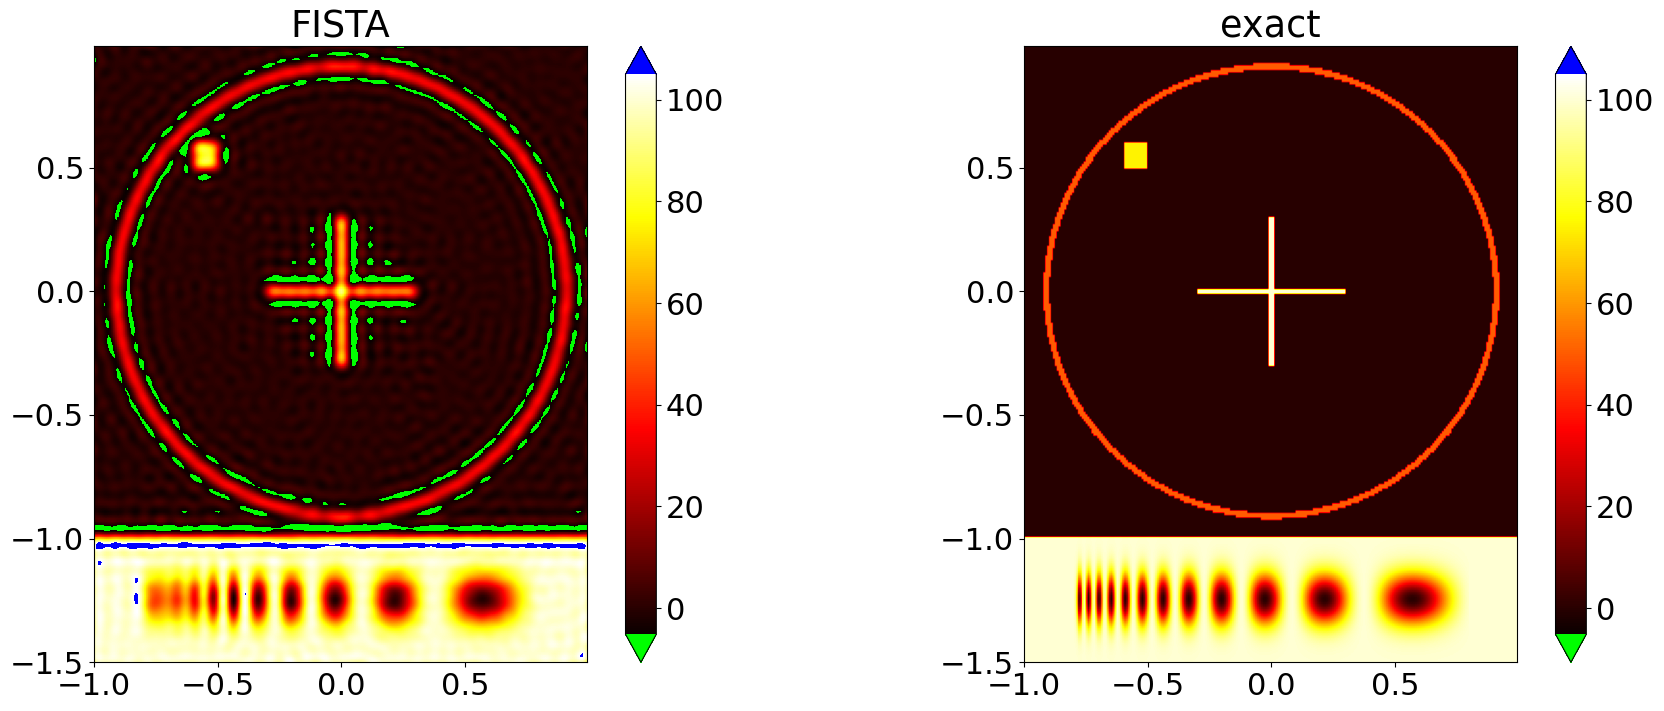

In [7]:
solverFISTA_dual = FISTA(dual_setting,logging_level=logging.DEBUG)
stop_FISTA_dual=DualityGapStopping(solverFISTA_dual,threshold = threshold, max_iter=max_iter,logging_level=logging.INFO)
pFISTA_dual, Tstar_pFISTA_dual= solverFISTA_dual.run(stoprule=stop_FISTA_dual)

f_FISTA_dual = huber_setting.dualToPrimal(Tstar_pFISTA_dual,argumentIsOperatorImage=True)
comparison_plot(grid,exact_sol,f_FISTA_dual,title_left='FISTA')

### PDHG


2024-07-07 18:50:08,508 INFO PDHG                 :: Using accelerated version 2 with convexity parameters mu_R=1.000e+00, mu_S*=1.000e-05 and ||T||=9.975e-01.
 Expected linear convergence rate: 9.937e-01
2024-07-07 18:50:08,550 INFO DualityGapStopping   :: it. 0/500: duality gap=1.105e+08 (1.000e-01)
2024-07-07 18:50:08,600 INFO DualityGapStopping   :: it. 1/500: duality gap=4.785e+07 (1.000e-01)
2024-07-07 18:50:08,647 INFO DualityGapStopping   :: it. 2/500: duality gap=3.955e+07 (1.000e-01)
2024-07-07 18:50:08,696 INFO DualityGapStopping   :: it. 3/500: duality gap=2.792e+07 (1.000e-01)
2024-07-07 18:50:08,752 INFO DualityGapStopping   :: it. 4/500: duality gap=1.014e+07 (1.000e-01)
2024-07-07 18:50:08,810 INFO DualityGapStopping   :: it. 5/500: duality gap=2.588e+06 (1.000e-01)
2024-07-07 18:50:08,853 INFO DualityGapStopping   :: it. 6/500: duality gap=1.357e+06 (1.000e-01)
2024-07-07 18:50:08,899 INFO DualityGapStopping   :: it. 7/500: duality gap=1.050e+06 (1.000e-01)
2024-07-07 

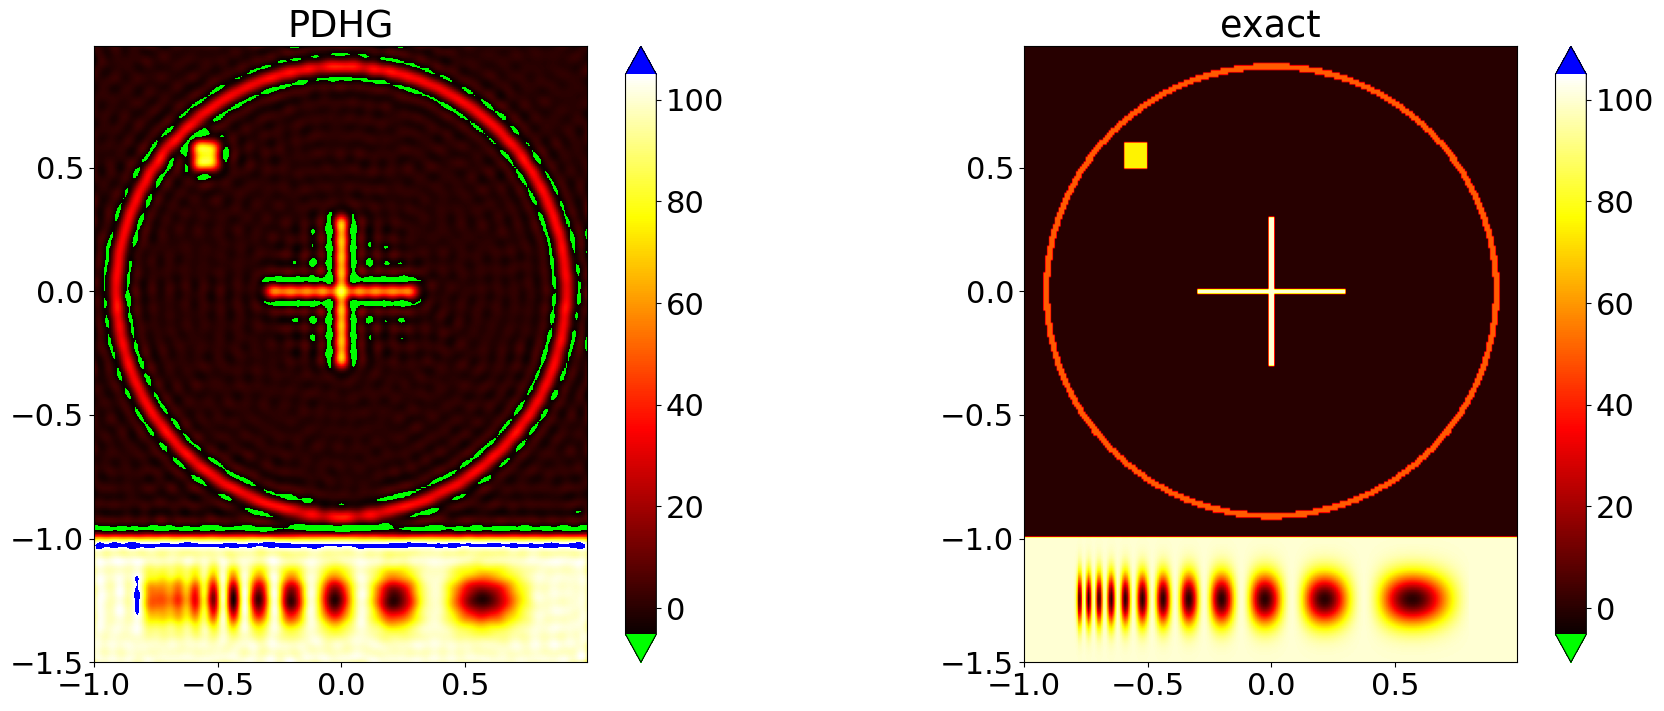

In [8]:
solverPDHG = PDHG(huber_setting,logging_level=logging.INFO)
stop_PDHG=DualityGapStopping(solverPDHG,threshold = threshold, max_iter=max_iter,logging_level=logging.INFO)
f_PDHG, _= solverPDHG.run(stoprule=stop_PDHG)

comparison_plot(grid,exact_sol,f_PDHG,title_left='PDHG')

### comparison of convergence rates of minimization methods

Text(0.5, 1.0, 'Huber data fid., quadratic penalty')

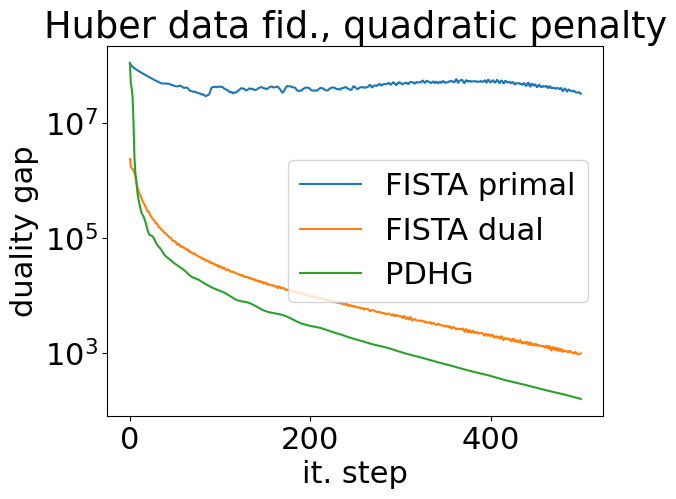

In [9]:
plt.semilogy(stop_FISTA_primal.gap_stat,label='FISTA primal')
plt.semilogy(stop_FISTA_dual.gap_stat,label='FISTA dual')
plt.semilogy(stop_PDHG.gap_stat,label='PDHG')
plt.legend()
plt.xlabel('it. step'); plt.ylabel('duality gap')
plt.title('Huber data fid., quadratic penalty')

# setting with Huber data fidelity and quadratic penalty term with bilateral constraints
We now set up a generalized Tikhonov regularization setting
$$
\hat{f} \in \mathrm{argmin}_{0\leq f\leq ub}\left[\frac{1}{\alpha}H_{\sigma}(Tf-g^{\mathrm{obs}})+\|f\|_{L^2}^2\right]    
$$
where the Huber data fidelity term $H_{\sigma}$ is quadratic on coordinates in $[-\sigma,\sigma]$ and $|\cdot|-\sigma/2$ for large coordinates.

We test three solvers for this setting:
- FISTA applied to the primal problem
- FISTA applied to the dual problem
- Primal-Dual Hybrid Gradient (Chambolle-Pock) method

In [10]:
sigma = 0.1
Sdat = (1./sigma)*fct.Huber(grid,sigma=sigma,eps=1e-10)
Rfun = fct.QuadraticBilateralConstraints(grid,lb=0,ub=100,eps=1e-10)
huber_constr_setting = TikhonovRegularizationSetting(conv,Rfun,Sdat,alpha,data_fid_shift=data,logging_level=logging.DEBUG)
dual_constr_setting = huber_constr_setting.dualSetting()
threshold =0.1
max_iter = 500

### FISTA applied to primal setting 

2024-07-07 18:50:36,231 INFO FISTA                :: Setting up FISTA with convexity parameters mu_R=1.000e-04, mu_S=0.000e+00 and step length tau=1.009e-01.
 Expected linear convergence rate: 9.968e-01
2024-07-07 18:50:36,265 INFO DualityGapStopping   :: it. 0/500: duality gap=2.635e+06 (1.000e-01)
2024-07-07 18:50:36,309 INFO DualityGapStopping   :: it. 1/500: duality gap=2.403e+06 (1.000e-01)
2024-07-07 18:50:36,361 INFO DualityGapStopping   :: it. 2/500: duality gap=2.292e+06 (1.000e-01)
2024-07-07 18:50:36,413 INFO DualityGapStopping   :: it. 3/500: duality gap=2.188e+06 (1.000e-01)
2024-07-07 18:50:36,459 INFO DualityGapStopping   :: it. 4/500: duality gap=2.100e+06 (1.000e-01)
2024-07-07 18:50:36,510 INFO DualityGapStopping   :: it. 5/500: duality gap=2.035e+06 (1.000e-01)
2024-07-07 18:50:36,555 INFO DualityGapStopping   :: it. 6/500: duality gap=1.981e+06 (1.000e-01)
2024-07-07 18:50:36,608 INFO DualityGapStopping   :: it. 7/500: duality gap=1.934e+06 (1.000e-01)
2024-07-07 18

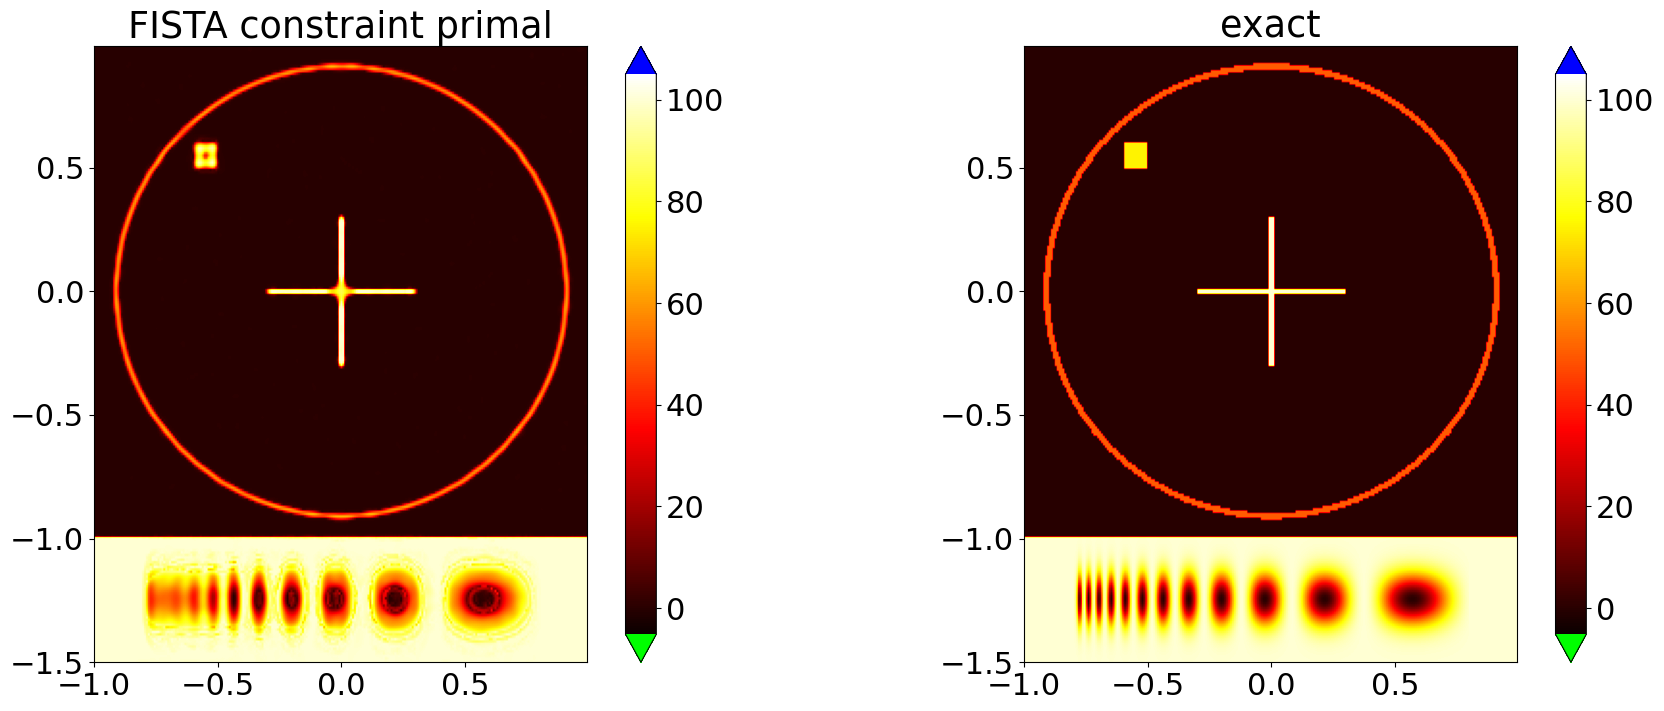

In [11]:
solverFISTA_constr_primal = FISTA(huber_constr_setting,logging_level=logging.DEBUG)
stop_FISTA_constr_primal=DualityGapStopping(solverFISTA_constr_primal,threshold = threshold, max_iter=max_iter,logging_level=logging.DEBUG)
f_FISTA_constr_primal, _= solverFISTA_constr_primal.run(stoprule=stop_FISTA_constr_primal)

comparison_plot(grid,exact_sol,f_FISTA_constr_primal,title_left='FISTA constraint primal')

### FISTA applied to the dual setting

2024-07-07 18:51:07,536 INFO FISTA                :: Setting up FISTA with convexity parameters mu_R=1.000e-05, mu_S=0.000e+00 and step length tau=1.010e+00.
 Expected linear convergence rate: 9.968e-01
2024-07-07 18:51:07,563 INFO DualityGapStopping   :: it. 0/500: duality gap=3.518e+06 (1.000e-01)
2024-07-07 18:51:07,603 INFO DualityGapStopping   :: it. 1/500: duality gap=1.683e+06 (1.000e-01)
2024-07-07 18:51:07,647 INFO DualityGapStopping   :: it. 2/500: duality gap=1.577e+06 (1.000e-01)
2024-07-07 18:51:07,684 INFO DualityGapStopping   :: it. 3/500: duality gap=1.470e+06 (1.000e-01)
2024-07-07 18:51:07,725 INFO DualityGapStopping   :: it. 4/500: duality gap=1.336e+06 (1.000e-01)
2024-07-07 18:51:07,765 INFO DualityGapStopping   :: it. 5/500: duality gap=1.168e+06 (1.000e-01)
2024-07-07 18:51:07,806 INFO DualityGapStopping   :: it. 6/500: duality gap=9.673e+05 (1.000e-01)
2024-07-07 18:51:07,846 INFO DualityGapStopping   :: it. 7/500: duality gap=7.416e+05 (1.000e-01)
2024-07-07 18

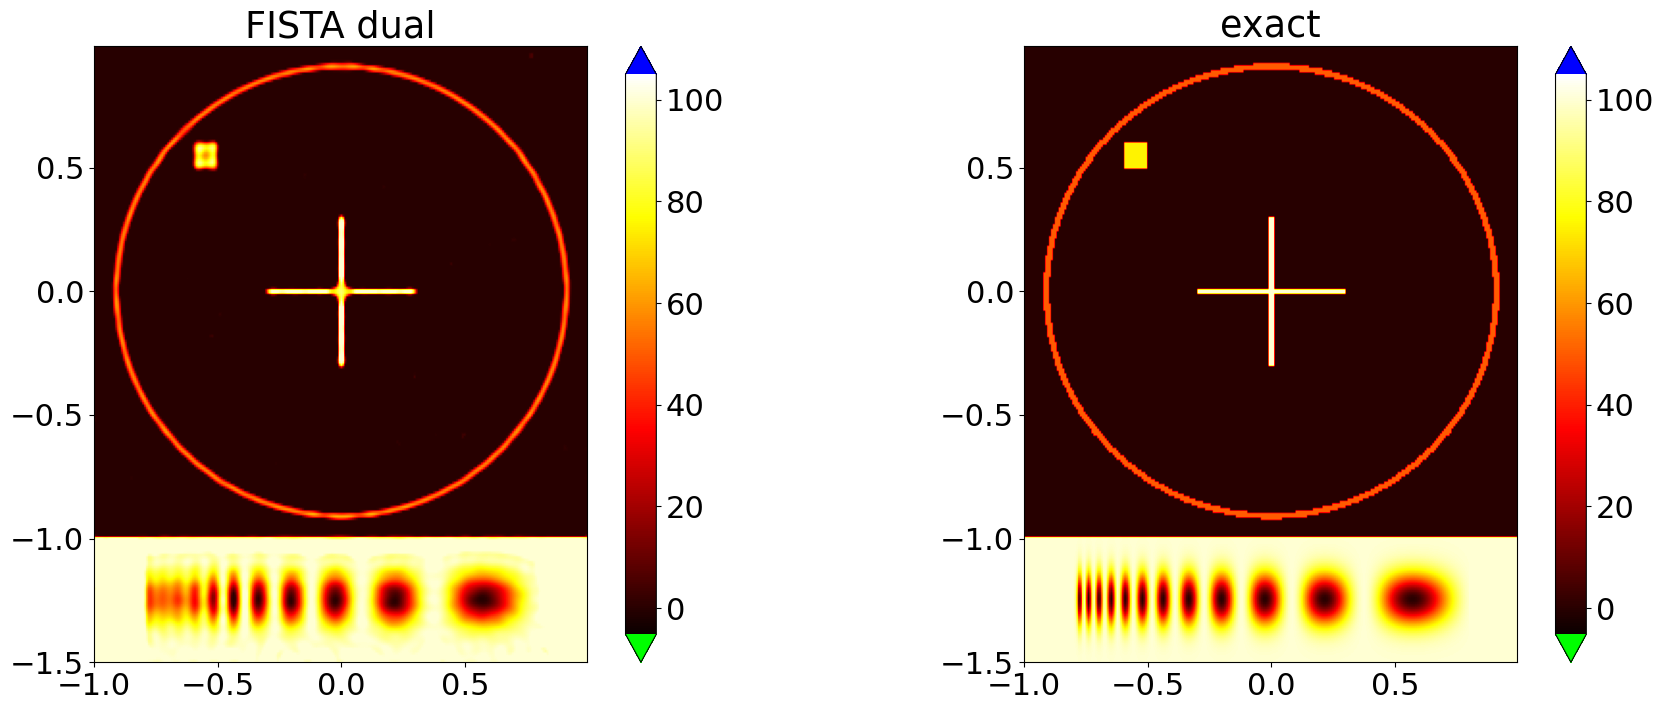

In [12]:
solverFISTA_constr_dual = FISTA(dual_constr_setting,logging_level=logging.DEBUG)
stop_FISTA_constr_dual=DualityGapStopping(solverFISTA_constr_dual,threshold = threshold, max_iter=max_iter,logging_level=logging.INFO)
pFISTA_constr_dual, Tstar_pFISTA_constr_dual= solverFISTA_constr_dual.run(stoprule=stop_FISTA_constr_dual)

f_FISTA_constr_dual = huber_constr_setting.dualToPrimal(Tstar_pFISTA_constr_dual,argumentIsOperatorImage=True)
comparison_plot(grid,exact_sol,f_FISTA_constr_dual,title_left='FISTA dual')

### PDHG

2024-07-07 18:51:33,248 INFO PDHG                 :: Using accelerated version 2 with convexity parameters mu_R=1.000e+00, mu_S*=1.000e-05 and ||T||=9.973e-01.
 Expected linear convergence rate: 9.937e-01
2024-07-07 18:51:33,274 INFO DualityGapStopping   :: it. 0/500: duality gap=2.635e+06 (1.000e-01)
2024-07-07 18:51:33,314 INFO DualityGapStopping   :: it. 1/500: duality gap=1.342e+06 (1.000e-01)
2024-07-07 18:51:33,361 INFO DualityGapStopping   :: it. 2/500: duality gap=7.784e+05 (1.000e-01)
2024-07-07 18:51:33,405 INFO DualityGapStopping   :: it. 3/500: duality gap=3.830e+05 (1.000e-01)
2024-07-07 18:51:33,448 INFO DualityGapStopping   :: it. 4/500: duality gap=1.640e+05 (1.000e-01)
2024-07-07 18:51:33,489 INFO DualityGapStopping   :: it. 5/500: duality gap=8.471e+04 (1.000e-01)
2024-07-07 18:51:33,526 INFO DualityGapStopping   :: it. 6/500: duality gap=5.783e+04 (1.000e-01)
2024-07-07 18:51:33,570 INFO DualityGapStopping   :: it. 7/500: duality gap=5.178e+04 (1.000e-01)
2024-07-07 

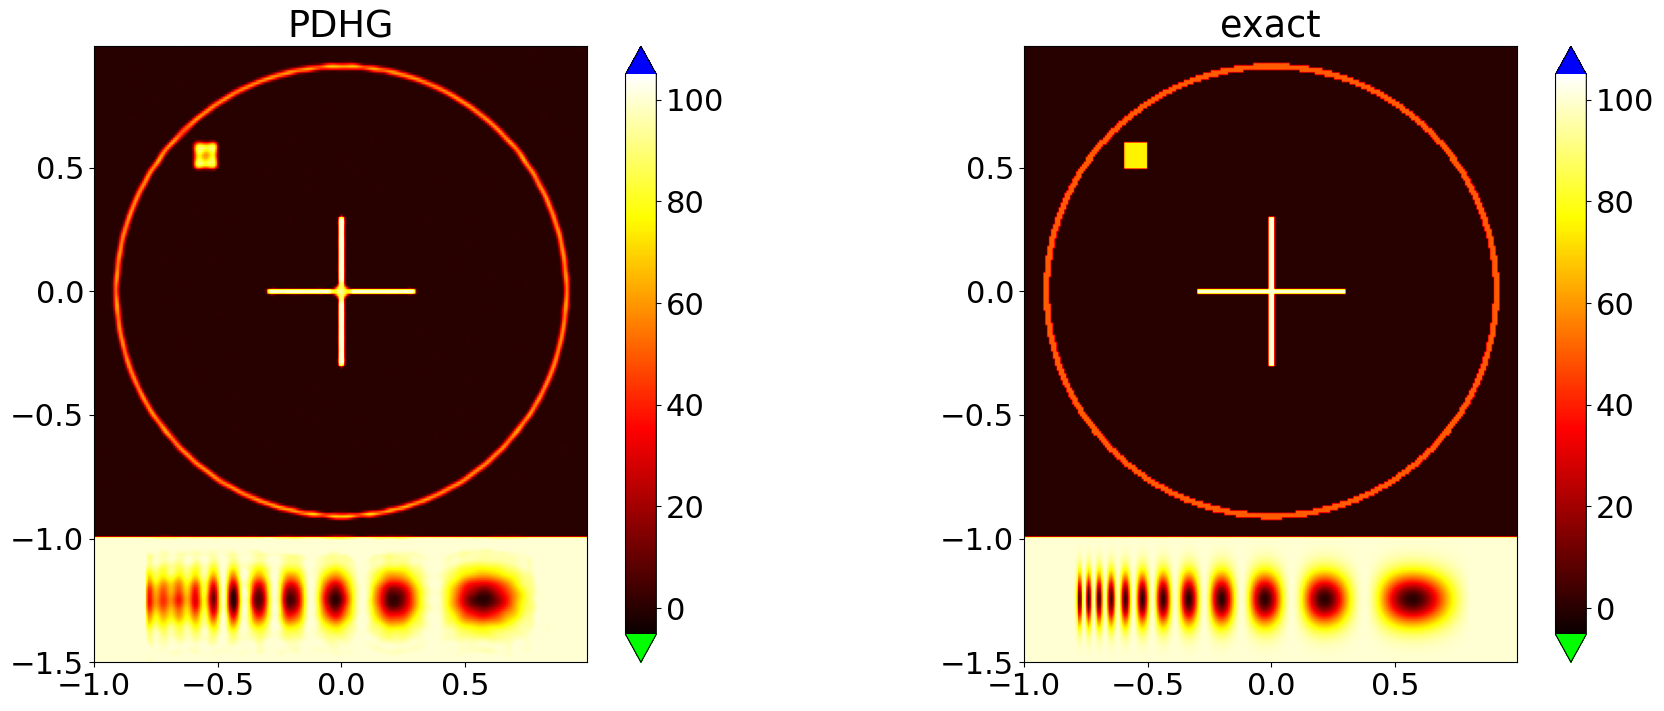

In [13]:
solverPDHG_constr = PDHG(huber_constr_setting,logging_level=logging.INFO)
stop_PDHG_constr=DualityGapStopping(solverPDHG_constr,threshold = threshold, max_iter=max_iter,logging_level=logging.INFO)
f_PDHG_constr, _= solverPDHG_constr.run(stoprule=stop_PDHG_constr)

comparison_plot(grid,exact_sol,f_PDHG_constr,title_left='PDHG')

### comparison of convergence rates of minimization methods

Text(0.5, 1.0, 'Huber data fid., quadratic constr. penalty')

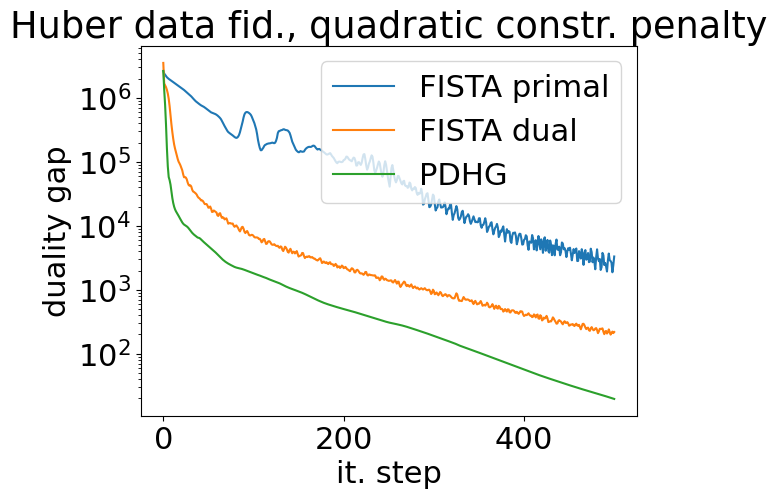

In [14]:
plt.semilogy(stop_FISTA_constr_primal.gap_stat,label='FISTA primal')
plt.semilogy(stop_FISTA_constr_dual.gap_stat,label='FISTA dual')
plt.semilogy(stop_PDHG_constr.gap_stat,label='PDHG')
plt.legend()
plt.xlabel('it. step'); plt.ylabel('duality gap')
plt.title('Huber data fid., quadratic constr. penalty')

# setting with \(L^1\) fidelity and quadratic penalty term with bilateral constraints
We now set up a generalized Tikhonov regularization setting
$$
\hat{f} \in \mathrm{argmin}_{0\leq f\leq ub}\left[\frac{1}{\alpha}\|Tf-g^{\mathrm{obs}}\|_{L^1}+\|f\|_{L^2}^2.\right]    
$$

We test two solvers for this setting:
- FISTA applied to the dual problem
- Primal-Dual Hybrid Gradient (Chambolle-Pock) method

In [ ]:

Sdat = fct.L1(grid)
Rfun = fct.QuadraticBilateralConstraints(grid,lb=0,ub=100,eps=1e-10)
huber_constr_setting = TikhonovRegularizationSetting(conv,Rfun,Sdat,alpha,data_fid_shift=data,logging_level=logging.DEBUG)
dual_constr_setting = huber_constr_setting.dualSetting()
threshold =0.1
max_iter = 500